# Mini Batch K-Means
Mini Batch K-Means is a variation of the K-Means clustering algorithm that is designed for large datasets. Instead of using the entire dataset for each iteration, it processes small, randomly selected mini-batches, which speeds up computation while maintaining performance.

# How Mini Batch K-Means Works
Initialize k cluster centers randomly.

Select a mini-batch of data points (instead of the full dataset).

Assign clusters: Each data point in the mini-batch is assigned to the nearest cluster center.

Update the centroids: The cluster centers are updated using the mini-batch, making the method computationally efficient.

Repeat steps 2-4 until convergence.

# Advantages
Faster than standard K-Means because it uses only a subset of data per iteration.

Scalable for large datasets.

Reduces memory usage, making it useful for streaming data.

# Disadvantages
Less accurate than full K-Means in some cases.

May converge to a suboptimal solution due to fewer updates per iteration.

# Implementation in Python
You can implement Mini Batch K-Means using sklearn:

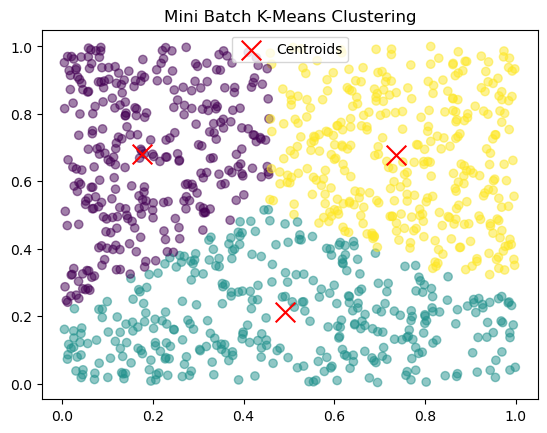

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import warnings

warnings.filterwarnings('ignore')

# Generate sample data
np.random.seed(42)
X = np.random.rand(1000, 2)  # 1000 points in 2D space

# Apply mini Batch K-Means
kmeans = MiniBatchKMeans(n_clusters=3,batch_size=50,random_state=42)
kmeans.fit(X)

# plot clusters
plt.scatter(X[:, 0],X[:,1],c=kmeans.labels_, cmap='viridis',alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='red',marker='x',s=200,label='Centroids')
plt.legend()
plt.title('Mini Batch K-Means Clustering')
plt.show()

# Project: Customer Segmentation Using Mini Batch K-Means
## Problem Statement
A retail company wants to segment its customers based on their purchasing behavior. Given a dataset containing customer transaction details, we will use Mini Batch K-Means to classify customers into different groups based on their spending patterns.

## Dataset: Customer Segmentation Dataset
We will use a sample dataset with the following columns:

Customer ID: Unique identifier for each customer

Annual Income: Customer's yearly income

Spending Score: A score (1-100) assigned based on customer spending behavior(100 means high spending)


In [15]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans


In [17]:
# Load dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\Mall_Customers.csv")
# Display first few rows
print(df.head(5))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [20]:
# Data Preprocessing
# Since clustering is based on numerical data, we select relevant columns and standardize them.

# Selecting relevant columns for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize the data to improve clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


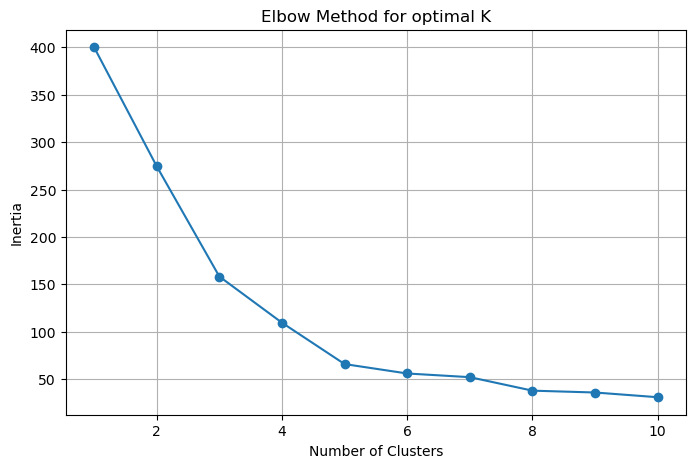

In [24]:
# Choosing the Optimal Number of Clusters (Elbow Method)
"""
To determine the best number of clusters, we plot the inertia 
(sum of squared distances from points to their assigned cluster center).
"""
inertia_values = []
K = range(1,11)

for k in K:
    kmeans = MiniBatchKMeans(n_clusters=k,batch_size=50,random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# plot the elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K,inertia_values, marker = 'o')
plt.grid()
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for optimal K')
plt.show()




In [37]:
#  Apply Mini Batch K-Means
# Applying Mini Batch K-Means
kmeans = MiniBatchKMeans(n_clusters=5,batch_size=50,random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# centroids
centroids = kmeans.cluster_centers_
print("Cluster Centers:\n", centroids)

Cluster Centers:
 [[-0.21318928 -0.03583994]
 [ 0.96874924  1.24674437]
 [ 0.99267614 -1.25106261]
 [-1.30222821  1.17121262]
 [-1.33039056 -1.07535723]]


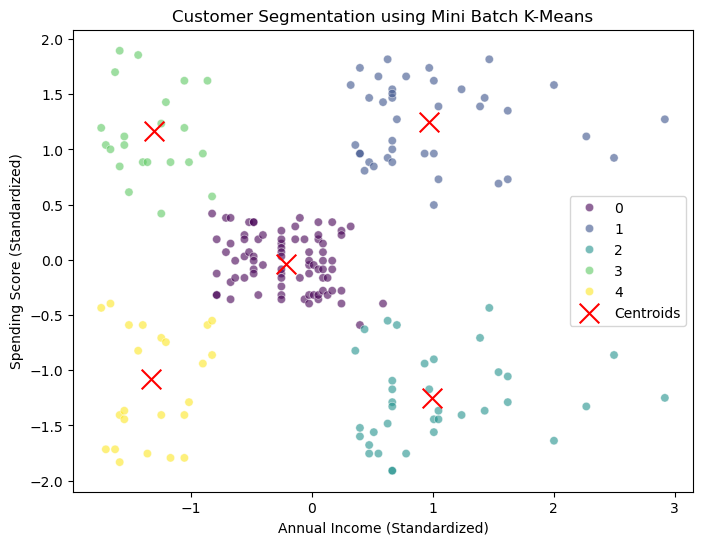

In [38]:
#  Visualizing the Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x = X_scaled[:, 0],y = X_scaled[:,1],hue=df['Cluster'],palette='viridis',alpha = 0.6)
plt.scatter(centroids[:,0],centroids[:,1],c = 'red', marker='x',s=200,label = 'Centroids')
plt.xlabel('Annual Income (Standardized)')
plt.ylabel('Spending Score (Standardized)')
plt.title('Customer Segmentation using Mini Batch K-Means')
plt.legend()
plt.show()

# Interpreting the Clusters
Cluster	    Customer  Behavior

Cluster 0	Medium Income, Medium Spending → Average Customers 

Cluster 1	High Income, High Spending → Luxury Shoppers 

Cluster 3	Low Income, High Spending → Impulsive Buyers 

Cluster 2	High Income, Low Spending → Careful Spenders 

Cluster 4	Low Income, Low Spending → Budget Conscious Customers 
